In [ ]:
from prometheus_pandas import query
import datetime as dt
from zoneinfo import ZoneInfo
import pandas as pd
import matplotlib.pyplot as plt

local_address = "gros-93.nancy.grid5000.fr"
local_port = "30090"
p = query.Prometheus(f"http://admin:prom-operator@{local_address}:{local_port}")    

local_tz = ZoneInfo("Europe/Paris")

def execute_query_range(experiment, metric_query, step, output_filename, plot=False):
    tput_series = []

    print("\nBeginning request execution")
    for label, config in experiment.items():    
        df_metric = p.query_range(
            query=metric_query,
            start=config['start'].isoformat(),
            end=config['end'].isoformat(),
            step=step
        )

        tput_series.append(df_metric)

    if tput_series:
        combined_df = pd.concat(tput_series, axis=1)
        combined_df.to_csv(output_filename, index_label='Time')
        print(f"\nFile saved : '{output_filename}'")
        if plot:
            plt.figure(figsize=(12, 8))
            ax = combined_df.boxplot(grid=True, patch_artist=True)
            plt.title(metric_query)
            plt.show()
    else:
        print("\nRequest Error")

### Experiment 1a

In [190]:
experiments = {
    'rocks': {
        'start': dt.datetime(2025, 7, 16, 11, 1, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 16, 11, 5, 0, tzinfo=local_tz)
    },
    'forst': {
        'start': dt.datetime(2025, 7, 16, 11, 10, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 16, 11, 15, 0, tzinfo=local_tz)
    },
    'forst_no_cache': {
        'start': dt.datetime(2025, 7, 16, 11, 20, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 16, 11, 25, 0, tzinfo=local_tz)
    }
}

experiments_10k = {
    'rocks': {
        'start': dt.datetime(2025, 7, 16, 14, 00, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 16, 14, 5, 0, tzinfo=local_tz)
    },
    'forst': {
        'start': dt.datetime(2025, 7, 16, 14, 20, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 16, 14, 25, 0, tzinfo=local_tz)
    },
    'forst_no_cache': {
        'start': dt.datetime(2025, 7, 16, 14, 30, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 16, 14, 35, 0, tzinfo=local_tz)
    }
}

### TPUT Measurement

In [191]:
metric_query = 'sum(flink_taskmanager_job_task_numRecordsOutPerSecond{component="taskmanager"})'
step = "5s"
output_filename = 'xp1results/50ktput/exp1a_50k_tput.csv'

execute_query_range(experiments, metric_query, step, output_filename)


Beginning request execution

File saved : 'xp1results/50ktput/exp1a_50k_tput.csv'


In [192]:
metric_query = 'sum(flink_taskmanager_job_task_numRecordsOutPerSecond{component="taskmanager"})'
step = "5s"
output_filename = 'xp1results/10ktput/exp1a_10k_tput.csv'

execute_query_range(experiments, metric_query, step, output_filename)


Beginning request execution

File saved : 'xp1results/10ktput/exp1a_10k_tput.csv'


### CPU Load

In [193]:
metric_query = 'flink_taskmanager_Status_JVM_CPU_Load{component="taskmanager"}'
step = "5s"
output_filename = 'xp1results/50ktput/exp1a_50k_cpu_load.csv'

execute_query_range(experiments, metric_query, step, output_filename)


Beginning request execution

File saved : 'xp1results/50ktput/exp1a_50k_cpu_load.csv'


In [194]:
metric_query = 'flink_taskmanager_Status_JVM_CPU_Load{component="taskmanager"}'
step = "5s"
output_filename = 'xp1results/10ktput/exp1a_10k_cpu_load.csv'

execute_query_range(experiments_10k, metric_query, step, output_filename)


Beginning request execution

File saved : 'xp1results/10ktput/exp1a_10k_cpu_load.csv'


### Chepointing time

In [195]:
metric_query = 'flink_jobmanager_job_lastCheckpointDuration{component="jobmanager"}'
step = "30s"
output_filename = 'xp1results/50ktput/exp1a_50k_cp_time.csv'

execute_query_range(experiments, metric_query, step, output_filename)


Beginning request execution

File saved : 'xp1results/50ktput/exp1a_50k_cp_time.csv'


In [196]:
metric_query = 'flink_jobmanager_job_lastCheckpointDuration{component="jobmanager"}'
step = "30s"
output_filename = 'xp1results/10ktput/exp1a_10k_cp_time.csv'

execute_query_range(experiments_10k, metric_query, step, output_filename)


Beginning request execution

File saved : 'xp1results/10ktput/exp1a_10k_cp_time.csv'


### Boxplot from file

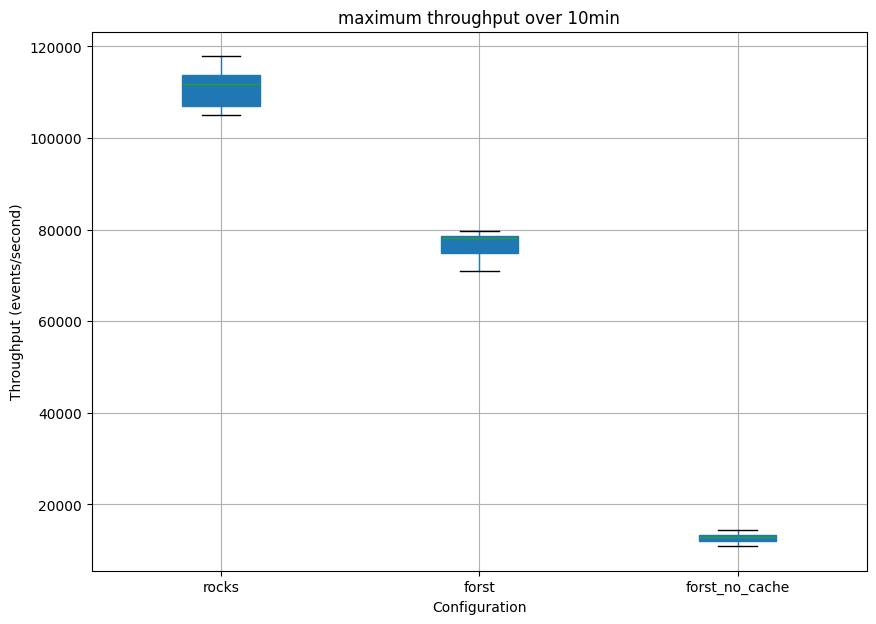

In [197]:
file_path = 'xp1results/maxtput/exp1a_maxtput_tput.csv'

try:
    # Charger les données en utilisant la première colonne comme index
    df = pd.read_csv(file_path, index_col=0)
    
    # Renommer les colonnes pour une meilleure lisibilité sur le graphique
    df.columns = ['rocks', 'forst', 'forst_no_cache']
    
    # Créer le boxplot
    plt.figure(figsize=(10, 7))
    df.boxplot(grid=True, patch_artist=True)
    
    # Ajouter les titres et les étiquettes
    plt.title('maximum throughput over 10min')
    plt.ylabel('Throughput (events/second)')
    plt.xlabel('Configuration')
    #plt.savefig('xp1results/boxplot_maxtput_10min.png')
    # Afficher le graphique
    plt.show()
    
except FileNotFoundError:
    print(f"Le fichier '{file_path}' est introuvable.")
except Exception as e:
    print(f"Une erreur est survenue : {e}")

<Figure size 1600x900 with 0 Axes>

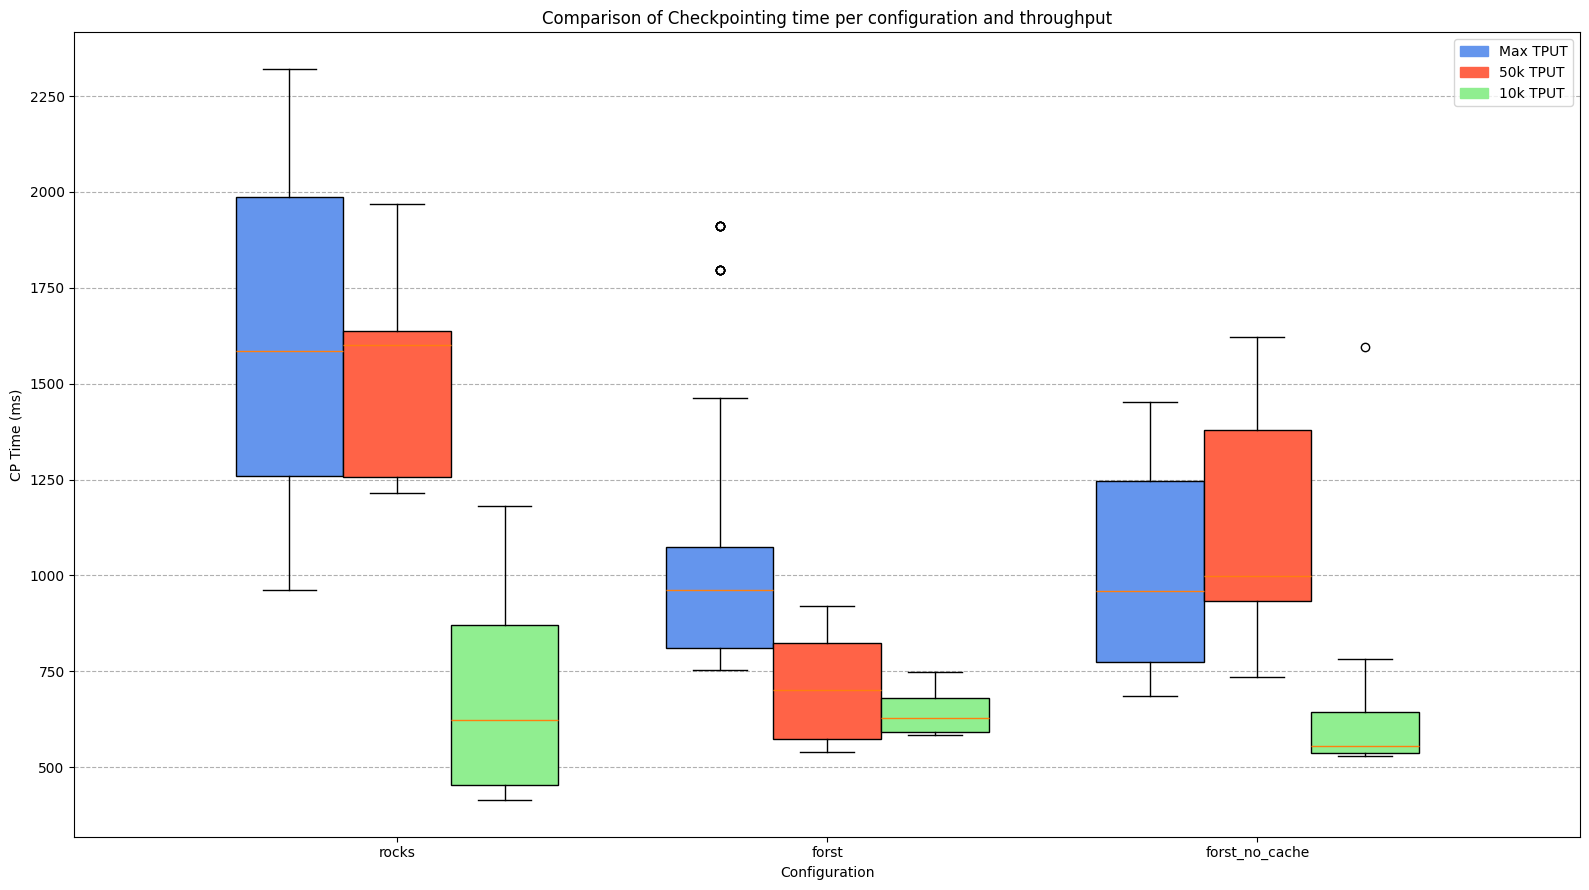

In [198]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# --- 1. Chargement des données des trois expériences ---

# Dictionnaires pour mapper les noms de fichiers aux configurations
files_50k = {'xp1results/50ktput/exp1a_50k_cp_time.csv': '50k TPUT'}
files_10k = {'xp1results/10ktput/exp1a_10k_cp_time.csv': '10k TPUT'}
files_maxtput = {'xp1results/maxtput/exp1a_maxtput_cp_time.csv': 'Max TPUT'}

def load_and_prepare_data(file_dict):
    """Charge un fichier CSV et prépare les données pour le boxplot."""
    file_path = list(file_dict.keys())[0]
    try:
        df = pd.read_csv(file_path, index_col=0)
        # S'assurer que les noms de colonnes sont propres
        df.columns = [col.split('{')[0].split('_')[-1] if '{' in col else col for col in df.columns]
        df.columns = ['rocks', 'forst', 'forst_no_cache']
        return df
    except FileNotFoundError:
        print(f"Erreur : Le fichier {file_path} est introuvable.")
        return None

df_50k = load_and_prepare_data(files_50k)
df_10k = load_and_prepare_data(files_10k)
df_maxtput = load_and_prepare_data(files_maxtput)

if df_50k is not None and df_10k is not None and df_maxtput is not None:
    # --- 2. Préparation des données pour le graphique ---
    labels = ['rocks', 'forst', 'forst_no_cache']
    data_50k = [df_50k[col].dropna() for col in labels]
    data_10k = [df_10k[col].dropna() for col in labels]
    data_maxtput = [df_maxtput[col].dropna() for col in labels]

    # --- 3. Création du Box Plot groupé ---
    plt.figure(figsize=(16, 9))
    fig, ax = plt.subplots(figsize=(16, 9))

    # Positions sur l'axe X
    x_positions = np.arange(len(labels))
    width = 0.25  # Largeur des boîtes

    # Dessiner les boîtes pour chaque débit
    bplot1 = ax.boxplot(data_maxtput, 
                        positions=x_positions - width, 
                        widths=width, 
                        patch_artist=True,
                        boxprops=dict(facecolor="cornflowerblue"))

    bplot2 = ax.boxplot(data_50k, 
                        positions=x_positions, 
                        widths=width, 
                        patch_artist=True,
                        boxprops=dict(facecolor="tomato"))

    bplot3 = ax.boxplot(data_10k, 
                        positions=x_positions + width, 
                        widths=width, 
                        patch_artist=True,
                        boxprops=dict(facecolor="lightgreen")) # Nouvelle couleur

    # --- 4. Personnalisation du graphique ---
    ax.set_ylabel('CP Time (ms)')
    ax.set_title('Comparison of Checkpointing time per configuration and throughput')
    
    # Étiquettes et graduations de l'axe X
    ax.set_xticks(x_positions)
    ax.set_xticklabels(labels)
    ax.set_xlabel('Configuration')

    # Grille horizontale
    ax.yaxis.grid(True, linestyle='--')

    # --- 5. Création de la légende ---
    legend_50k = mpatches.Patch(color='cornflowerblue', label='Max TPUT')
    legend_10k = mpatches.Patch(color='tomato', label='50k TPUT')
    legend_maxtput = mpatches.Patch(color='lightgreen', label='10k TPUT') # Nouvelle légende
    ax.legend(handles=[legend_50k, legend_10k, legend_maxtput])

    # Ajuster et sauvegarder
    fig.tight_layout()
    plt.savefig('xp1results/boxplot_cp_time_comparison.png', dpi=300)
    plt.show()